In [1]:
!pip install ucimlrepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Tải dữ liệu
bike_sharing = fetch_ucirepo(id=275)

# Trích xuất dữ liệu
X = bike_sharing.data.features
y = bike_sharing.data.targets

# Kết hợp dữ liệu
data = pd.concat([X, y], axis=1)

In [3]:
# Hiển thị thông tin cơ bản về dữ liệu
print(f"Kích thước dữ liệu: {data.shape}")
print("\nThông tin các cột:")
print(data.info())
print("\nThống kê mô tả:")
print(data.describe())

Kích thước dữ liệu: (17379, 14)

Thông tin các cột:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  object 
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 1.9+ MB
None

Thống kê mô tả:
             season            yr          mnth            hr       holiday  \
count  17379.000000 

In [4]:
data

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,119
17375,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,89
17376,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,90
17377,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,61


In [5]:

# Chuyển đổi cột thời gian sang định dạng datetime
data['dteday'] = pd.to_datetime(data['dteday'])

# Tạo cột datetime kết hợp ngày và giờ
data['datetime'] = data['dteday'] + pd.to_timedelta(data['hr'], unit='h')
# Đặt datetime làm index
data_ts = data.set_index('datetime')
print("\nDữ liệu sau khi chuyển đổi:")
data_ts


Dữ liệu sau khi chuyển đổi:


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
datetime,,,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,16
2011-01-01 01:00:00,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,40
2011-01-01 02:00:00,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,32
2011-01-01 03:00:00,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,13
2011-01-01 04:00:00,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,119
2012-12-31 20:00:00,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,89
2012-12-31 21:00:00,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,90


In [6]:
print(data_ts.isnull().sum())

dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


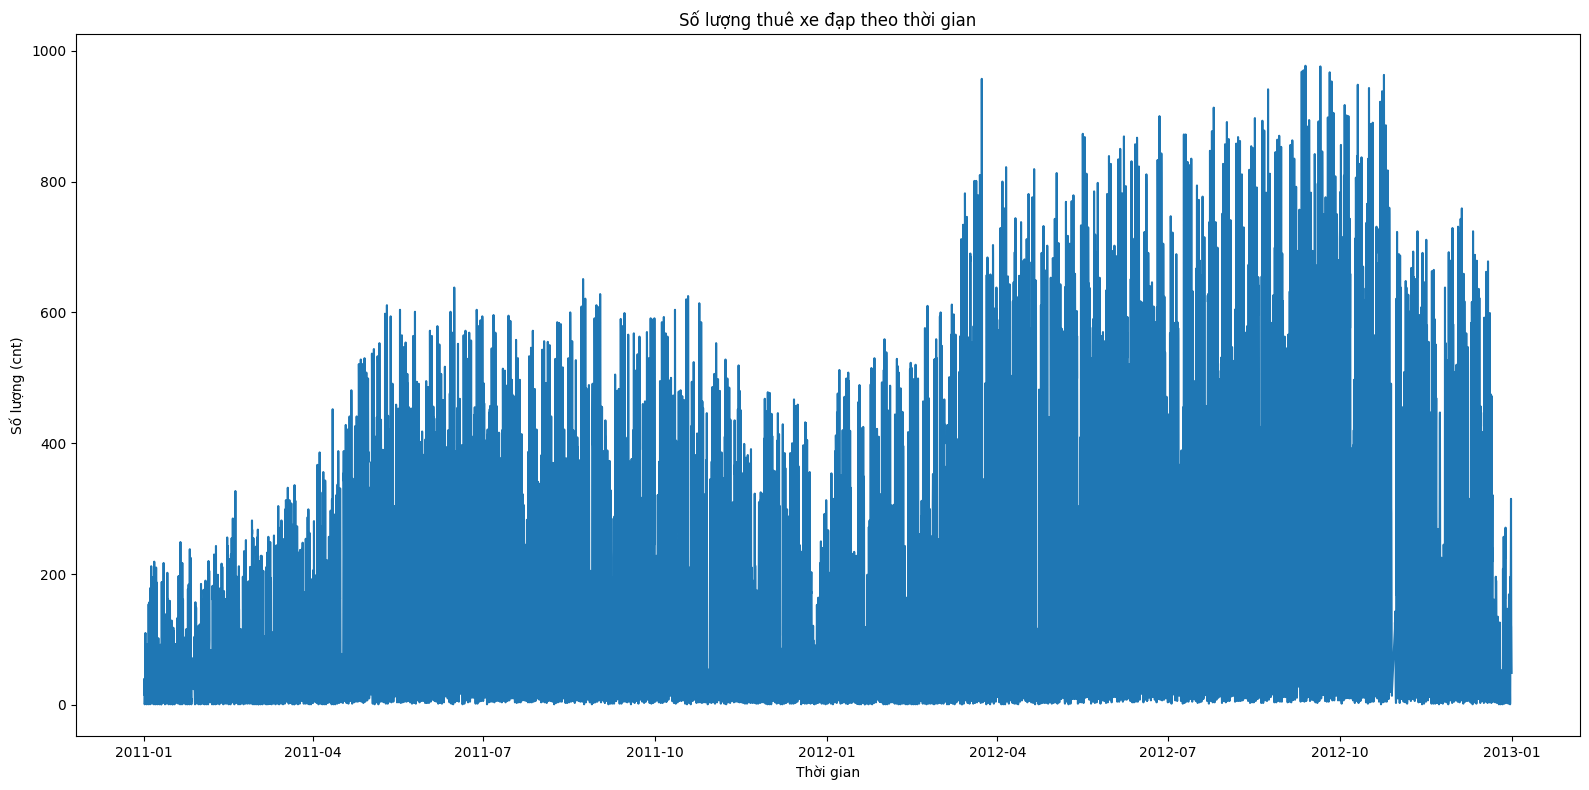

In [7]:
# Biểu đồ chuỗi thời gian của số lượng thuê xe đạp
plt.figure(figsize=(16, 8))
plt.plot(data_ts['cnt'])
plt.title('Số lượng thuê xe đạp theo thời gian')
plt.xlabel('Thời gian')
plt.ylabel('Số lượng (cnt)')
plt.tight_layout()
plt.show()



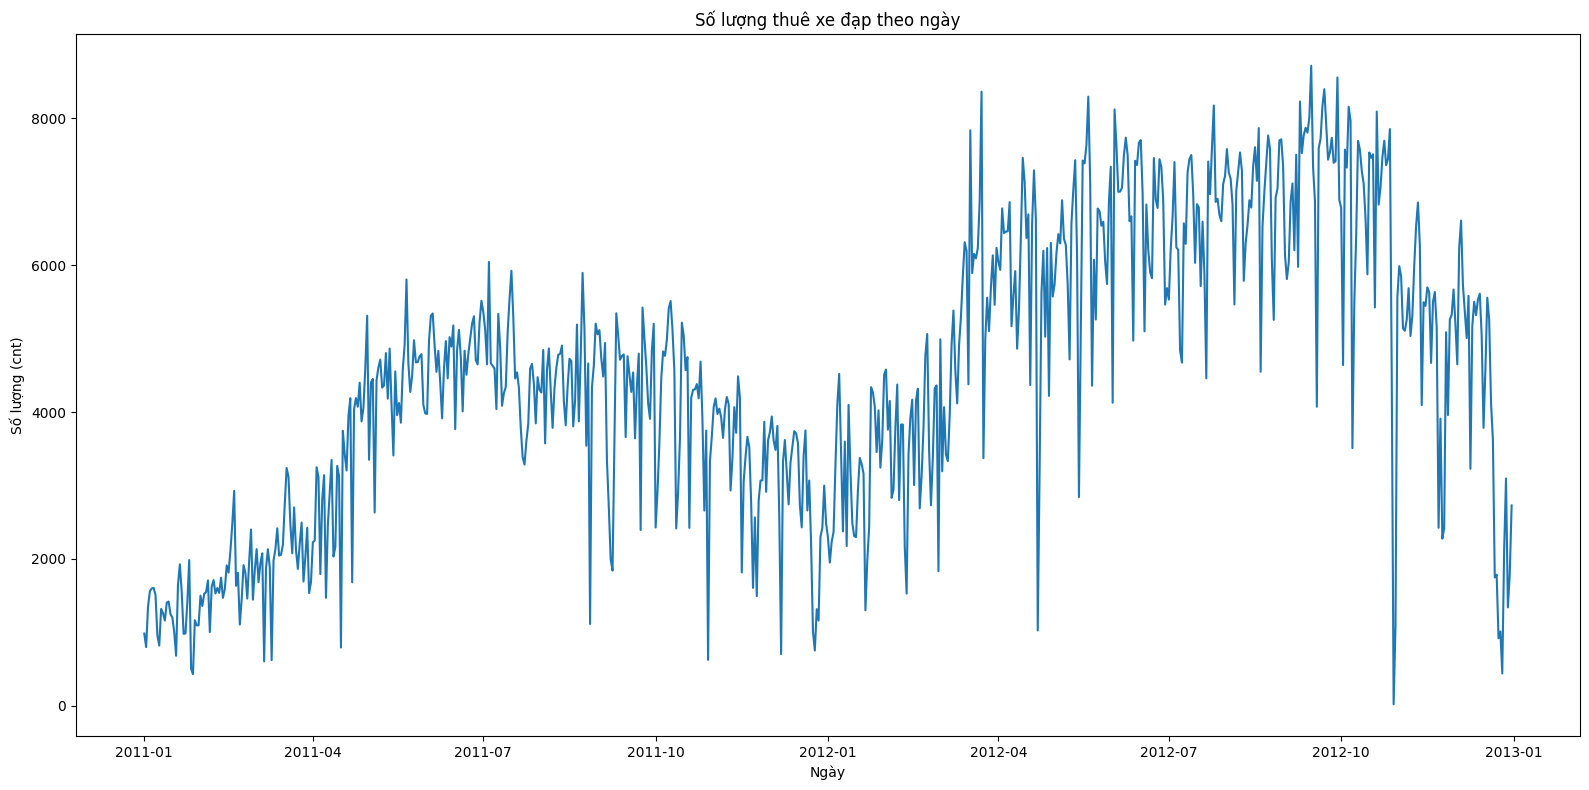

In [8]:

# Tạo dữ liệu tổng hợp theo ngày
daily_data = data_ts.groupby(data_ts.index.date)['cnt'].sum().reset_index()
daily_data['datetime'] = pd.to_datetime(daily_data['index'])
daily_data = daily_data.set_index('datetime')

# Biểu đồ số lượng thuê xe đạp theo ngày
plt.figure(figsize=(16, 8))
plt.plot(daily_data['cnt'])
plt.title('Số lượng thuê xe đạp theo ngày')
plt.xlabel('Ngày')
plt.ylabel('Số lượng (cnt)')
plt.tight_layout()
plt.show()

Chuỗi thời gian của số lượng thuê xe đạp có xu hướng tăng dần theo thời gian, đặc biệt là sự khác biệt rõ rệt giữa năm 2011 và 2012.

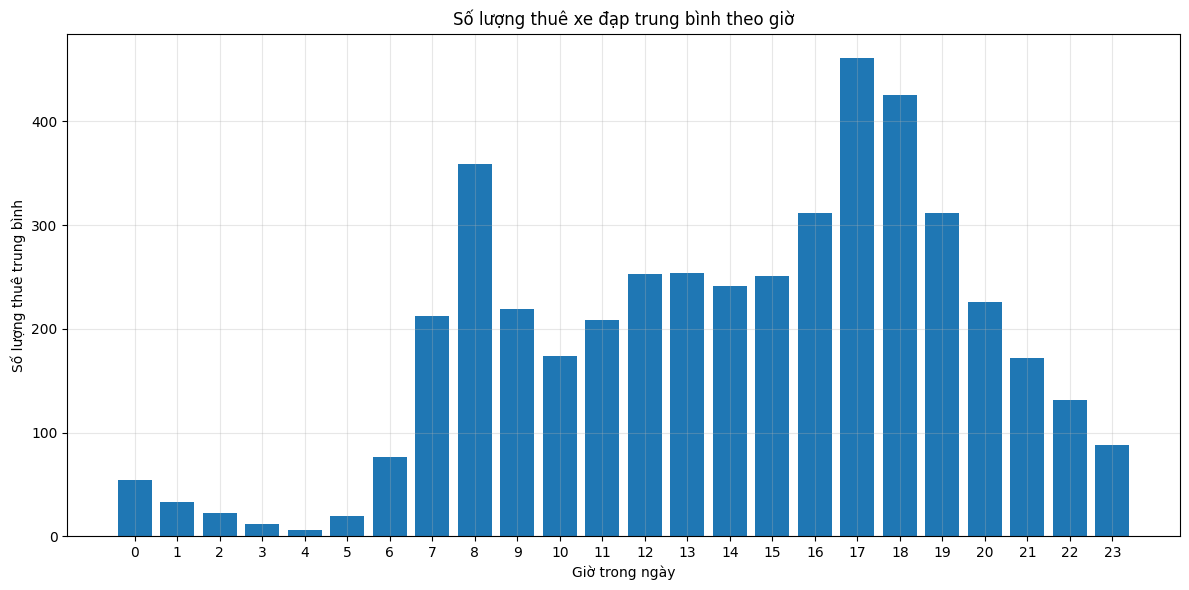

In [9]:

# Phân tích theo giờ trong ngày
hourly_pattern = data_ts.groupby(data_ts.index.hour)['cnt'].mean()
plt.figure(figsize=(12, 6))
plt.bar(hourly_pattern.index, hourly_pattern.values)
plt.title('Số lượng thuê xe đạp trung bình theo giờ')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Số lượng thuê trung bình')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Có hai đỉnh rõ rệt vào khoảng 8h sáng và 17-18h chiều, tương ứng với giờ đi làm và tan làm.

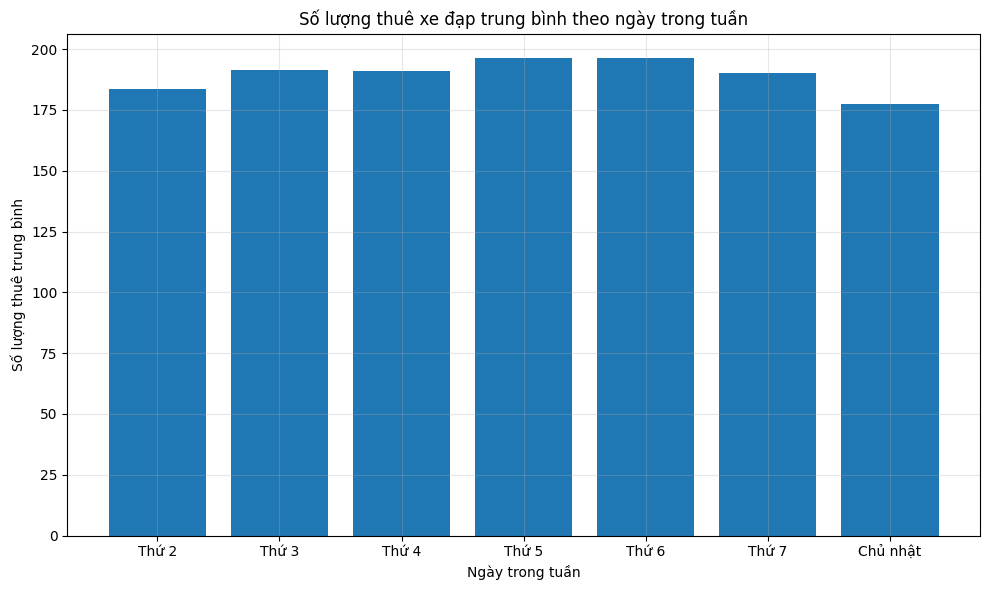

In [10]:

# Phân tích theo ngày trong tuần
weekday_pattern = data_ts.groupby(data_ts.index.dayofweek)['cnt'].mean()
plt.figure(figsize=(10, 6))
days = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ nhật']
plt.bar(days, weekday_pattern.values)
plt.title('Số lượng thuê xe đạp trung bình theo ngày trong tuần')
plt.xlabel('Ngày trong tuần')
plt.ylabel('Số lượng thuê trung bình')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Số lượng thuê xe đạp cao hơn vào các ngày làm việc so với cuối tuần.

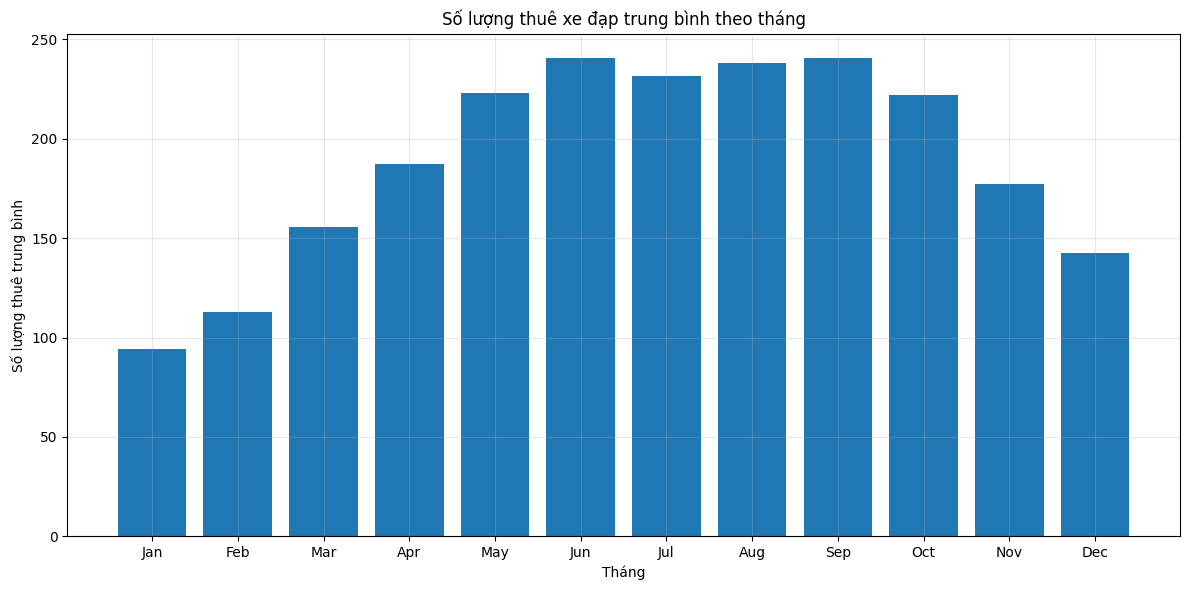

In [11]:

# Phân tích theo tháng
monthly_pattern = data_ts.groupby(data_ts.index.month)['cnt'].mean()
plt.figure(figsize=(12, 6))
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.bar(months, monthly_pattern.values)
plt.title('Số lượng thuê xe đạp trung bình theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Số lượng thuê trung bình')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Số lượng thuê xe đạp thấp vào tháng 1, 2, 11, 12 (mùa đông) và cao vào tháng 5-10 (mùa xuân và hè).

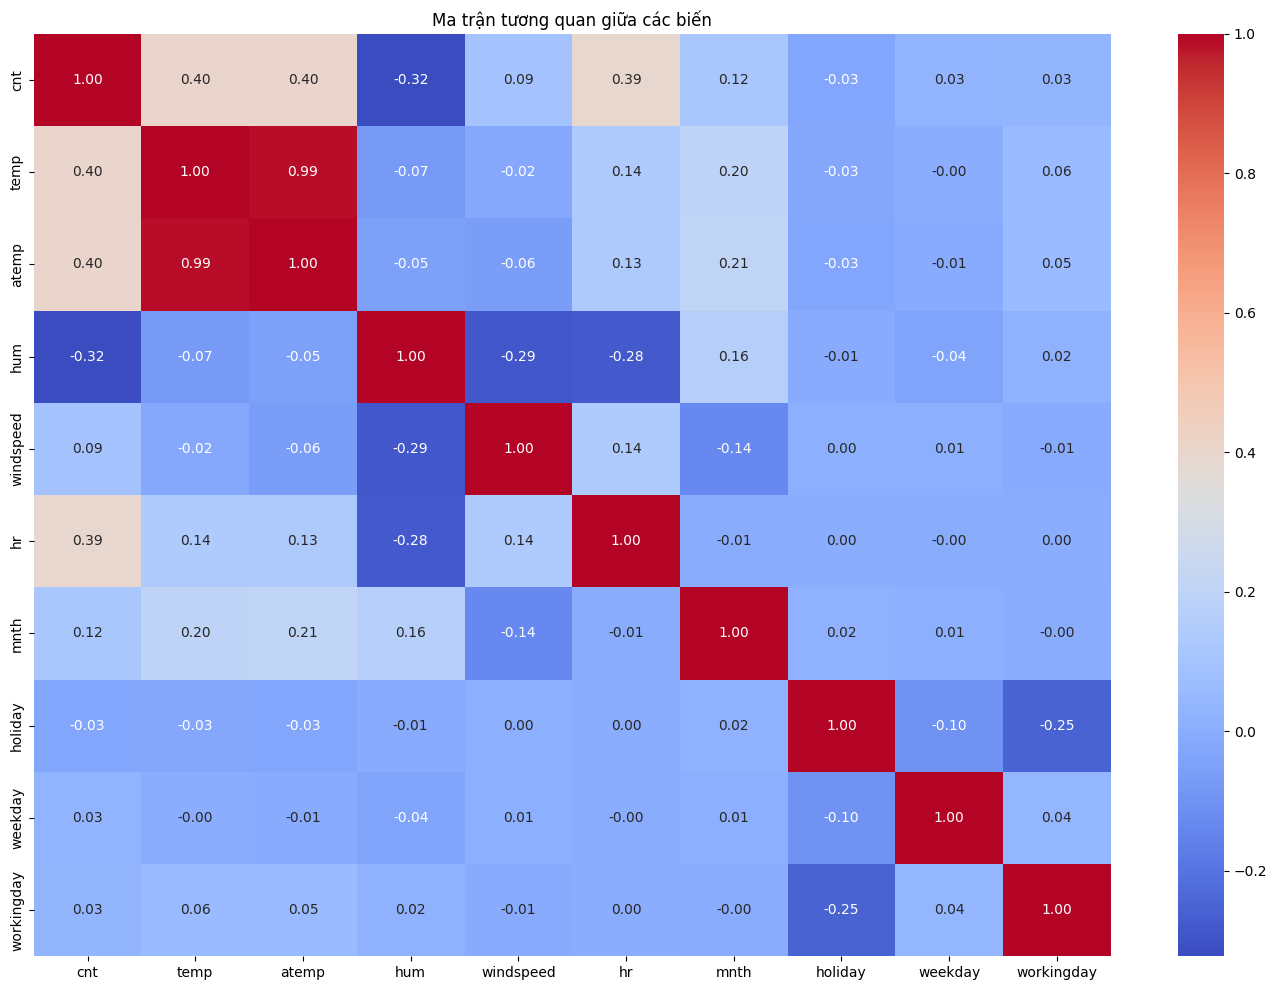

In [12]:

# Phân tích tương quan giữa các biến
plt.figure(figsize=(14, 10))
correlation_vars = ['cnt', 'temp', 'atemp', 'hum', 'windspeed', 'hr', 'mnth', 'holiday', 'weekday', 'workingday']
sns.heatmap(data_ts[correlation_vars].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các biến')
plt.tight_layout()
plt.show()


temp (nhiệt độ) và atemp (nhiệt độ cảm nhận) có tương quan dương cao với cnt.
hr (giờ trong ngày) có tương quan khá cao với cnt, phản ánh tính chu kỳ theo giờ.
hum (độ ẩm) có tương quan âm với cnt, cho thấy người dùng ít thuê xe hơn khi độ ẩm cao.

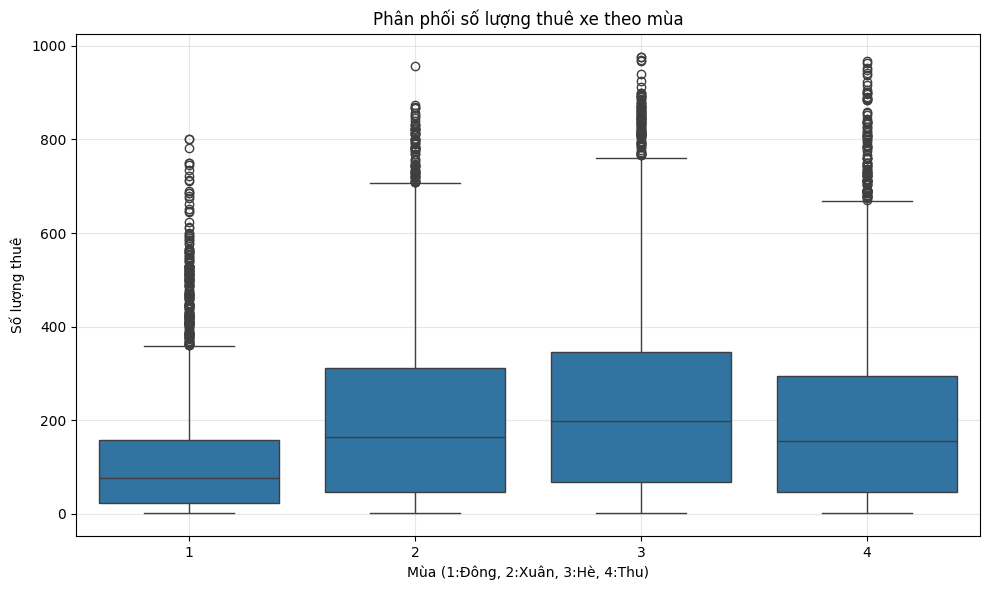

In [13]:

# Box plot theo mùa
plt.figure(figsize=(10, 6))
sns.boxplot(x='season', y='cnt', data=data_ts)
plt.title('Phân phối số lượng thuê xe theo mùa')
plt.xlabel('Mùa (1:Đông, 2:Xuân, 3:Hè, 4:Thu)')
plt.ylabel('Số lượng thuê')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

lượng thuê xe tăng cao vào mùa xuân và mùa hè, giảm vào mùa đông.

In [14]:
# Kiểm định ADF
result = adfuller(data_ts['cnt'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])
if result[1] < 0.05:
    print("Kết luận: Chuỗi dừng (stationary)")
else:
    print("Kết luận: Chuỗi không dừng (non-stationary)")

ADF Statistic: -6.822918711895102
p-value: 1.980862627797737e-09
Critical Values: {'1%': np.float64(-3.430727265144117), '5%': np.float64(-2.8617067365231246), '10%': np.float64(-2.5668587495404225)}
Kết luận: Chuỗi dừng (stationary)


Từ kết quả kiểm định ADF, p-value < 0.05, cho thấy chuỗi đã dừng. Do đó, chúng ta có thể sử dụng d=0 trong mô hình ARIMA.


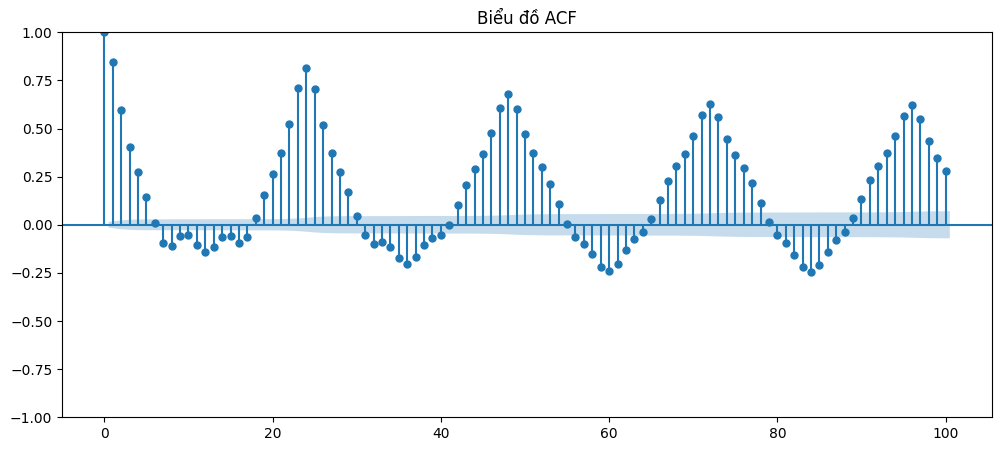

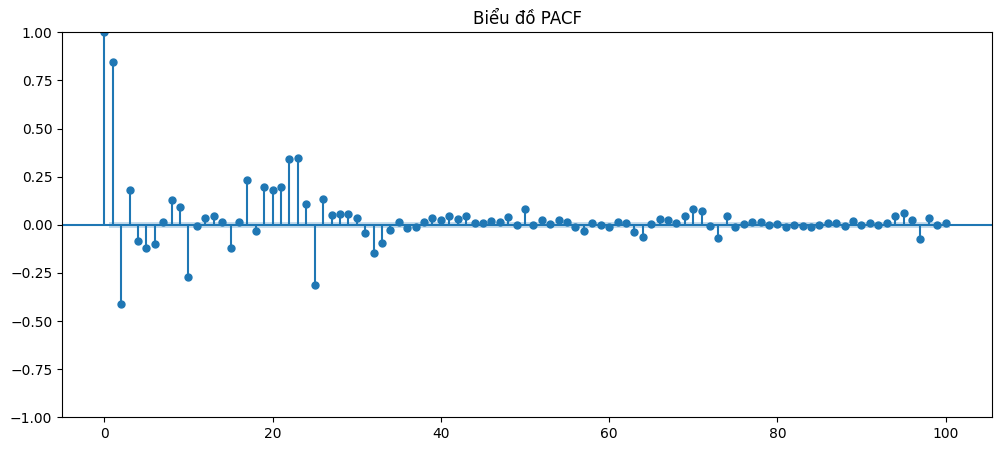

In [15]:
# Vẽ ACF, PACF
plt.figure(figsize=(12, 5))
plot_acf(data_ts['cnt'], lags=100, ax=plt.gca())
plt.title("Biểu đồ ACF")
plt.show()

plt.figure(figsize=(12, 5))
plot_pacf(data_ts['cnt'], lags=100, ax=plt.gca())
plt.title("Biểu đồ PACF")
plt.show()

Xác định tham số:
  -  p: từ PACF, có thể thấy độ trễ có ý nghĩa tại lag 1, 2 → p=2
  - d: chuỗi đã dừng, nên d=0
  -Chu kỳ mùa vụ s=24 giờ
  
Biểu đồ ACF cho thấy độ tương quan có chu kỳ rõ rệt tại các lag 24, 48, 72... giờ, xác nhận tính chu kỳ ngày (24 giờ).
Phân rã thành phần chuỗi thể hiện rõ thành phần xu hướng (trend) tăng dần và thành phần mùa vụ (seasonal) có chu kỳ 24 giờ.




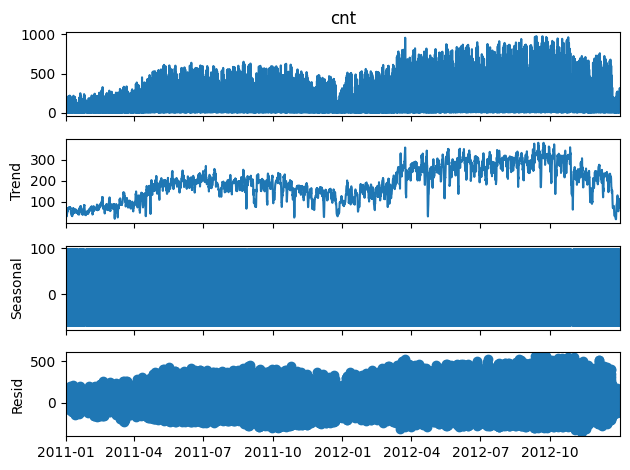

In [16]:
# Phân tích thành phần chuỗi
decomp = seasonal_decompose(data_ts['cnt'], model='additive', period=24)
decomp.plot()
plt.tight_layout()
plt.show()

In [17]:
data_ts = data_ts.dropna()

In [18]:
# Chuẩn hóa index theo giờ và điền giá trị thiếu
data_ts = data_ts.asfreq('h')  # hoặc 'H'
data_ts['cnt'] = data_ts['cnt'].interpolate()  # hoặc fillna(method='ffill')

# Chia tập train/test (7 ngày cuối làm test)
train = data_ts[:-168]
test = data_ts[-168:]

# Tách biến ngoại sinh cho ARIMAX/SARIMAX
exog_vars = ['temp', 'holiday', 'weekday']
train_exog = train[exog_vars]
test_exog = test[exog_vars]

print("Kích thước tập train:", train.shape)
print("Kích thước tập test:", test.shape)

Kích thước tập train: (17376, 14)
Kích thước tập test: (168, 14)


📌 ARIMA:
MAE: 122.26, RMSE: 134.52, MAPE: 1512.53%


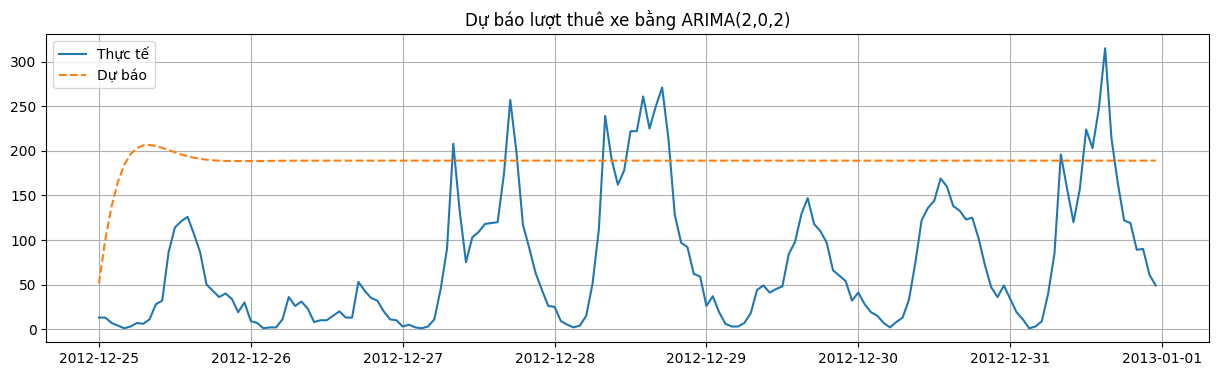

In [19]:
# ARIMA(p,d,q) với p=2, d=0, q=2
model_arima = ARIMA(train['cnt'], order=(2,0,2))
model_fit_arima = model_arima.fit()

# Dự báo
forecast_arima = model_fit_arima.forecast(steps=len(test))
forecast_arima = pd.Series(forecast_arima, index=test.index)

# Đánh giá
mae_arima = mean_absolute_error(test['cnt'], forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test['cnt'], forecast_arima))
mape_arima = np.mean(np.abs((test['cnt'] - forecast_arima) / test['cnt'])) * 100

print("📌 ARIMA:")
print(f"MAE: {mae_arima:.2f}, RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.2f}%")

# Vẽ biểu đồ
plt.figure(figsize=(15,4))
plt.plot(test['cnt'], label="Thực tế")
plt.plot(forecast_arima, label="Dự báo", linestyle='--')
plt.title("Dự báo lượt thuê xe bằng ARIMA(2,0,2)")
plt.legend()
plt.grid()
plt.show()

📌 SARIMA:
MAE: 113.72, RMSE: 151.11, MAPE: 423.96%


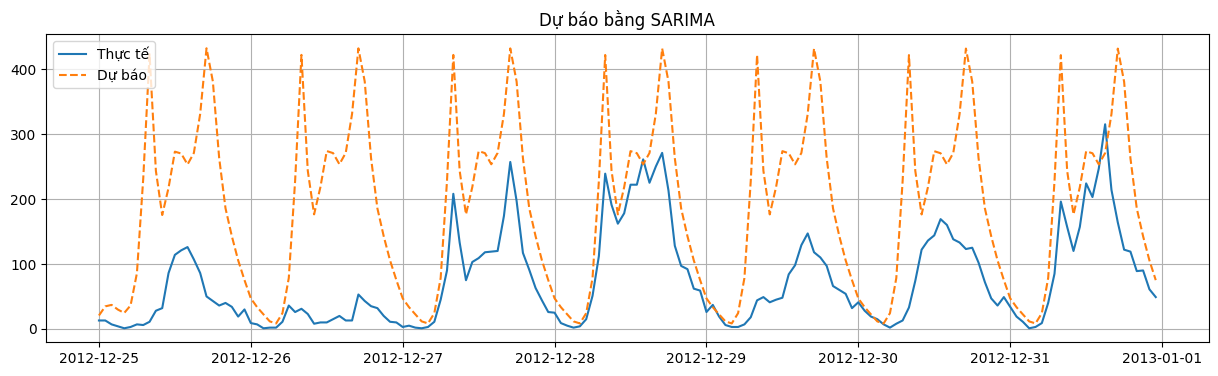

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
# SARIMA(p,d,q)(P,D,Q,s)
model_sarima = SARIMAX(train['cnt'], order=(2,0,2), seasonal_order=(1,0,1,24))
model_fit_sarima = model_sarima.fit(disp=False)

# Dự báo
forecast_sarima = model_fit_sarima.forecast(steps=len(test))
forecast_sarima = pd.Series(forecast_sarima, index=test.index)

# Đánh giá
mae_sarima = mean_absolute_error(test['cnt'], forecast_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test['cnt'], forecast_sarima))
mape_sarima = np.mean(np.abs((test['cnt'] - forecast_sarima) / test['cnt'])) * 100

print("📌 SARIMA:")
print(f"MAE: {mae_sarima:.2f}, RMSE: {rmse_sarima:.2f}, MAPE: {mape_sarima:.2f}%")

# Vẽ biểu đồ
plt.figure(figsize=(15,4))
plt.plot(test['cnt'], label="Thực tế")
plt.plot(forecast_sarima, label="Dự báo", linestyle='--')
plt.title("Dự báo bằng SARIMA")
plt.legend()
plt.grid()
plt.show()

📌 ARIMAX:
MAE: 62.03, RMSE: 72.26, MAPE: 692.47%


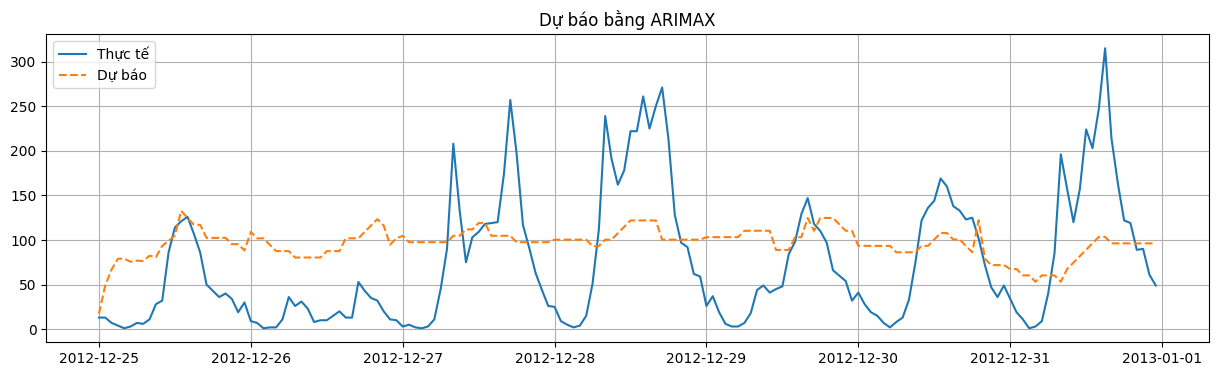

In [29]:
# Tách biến ngoại sinh cho ARIMAX/SARIMAX
exog_vars = ['temp', 'holiday', 'weekday']
train_exog = train[exog_vars]
test_exog = test[exog_vars]
# ARIMAX(p,d,q) với biến ngoại sinh
model_arimax = SARIMAX(train['cnt'], exog=train_exog, order=(2,0,2))
model_fit_arimax = model_arimax.fit(disp=False)

# Dự báo
forecast_arimax = model_fit_arimax.forecast(steps=len(test), exog=test_exog)
forecast_arimax = pd.Series(forecast_arimax, index=test.index)

# Đánh giá
mae_arimax = mean_absolute_error(test['cnt'], forecast_arimax)
rmse_arimax = np.sqrt(mean_squared_error(test['cnt'], forecast_arimax))
mape_arimax = np.mean(np.abs((test['cnt'] - forecast_arimax) / test['cnt'])) * 100

print("📌 ARIMAX:")
print(f"MAE: {mae_arimax:.2f}, RMSE: {rmse_arimax:.2f}, MAPE: {mape_arimax:.2f}%")

# Vẽ biểu đồ
plt.figure(figsize=(15,4))
plt.plot(test['cnt'], label="Thực tế")
plt.plot(forecast_arimax, label="Dự báo", linestyle='--')
plt.title("Dự báo bằng ARIMAX")
plt.legend()
plt.grid()
plt.show()

📌 SARIMAX:
MAE: 83.91, RMSE: 114.55, MAPE: 514.78%


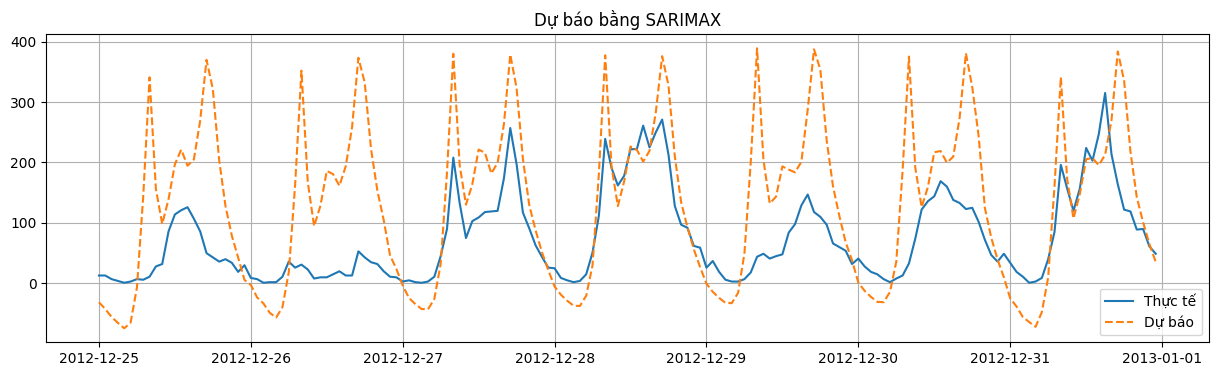

In [30]:
# SARIMAX
model_sarimax = SARIMAX(train['cnt'], exog=train_exog, order=(2,0,2), seasonal_order=(1,0,1,24))
model_fit_sarimax = model_sarimax.fit(disp=False)

# Dự báo
forecast_sarimax = model_fit_sarimax.forecast(steps=len(test), exog=test_exog)
forecast_sarimax = pd.Series(forecast_sarimax, index=test.index)

# Đánh giá
mae_sarimax = mean_absolute_error(test['cnt'], forecast_sarimax)
rmse_sarimax = np.sqrt(mean_squared_error(test['cnt'], forecast_sarimax))
mape_sarimax = np.mean(np.abs((test['cnt'] - forecast_sarimax) / test['cnt'])) * 100

print("📌 SARIMAX:")
print(f"MAE: {mae_sarimax:.2f}, RMSE: {rmse_sarimax:.2f}, MAPE: {mape_sarimax:.2f}%")

# Vẽ biểu đồ
plt.figure(figsize=(15,4))
plt.plot(test['cnt'], label="Thực tế")
plt.plot(forecast_sarimax, label="Dự báo", linestyle='--')
plt.title("Dự báo bằng SARIMAX")
plt.legend()
plt.grid()
plt.show()

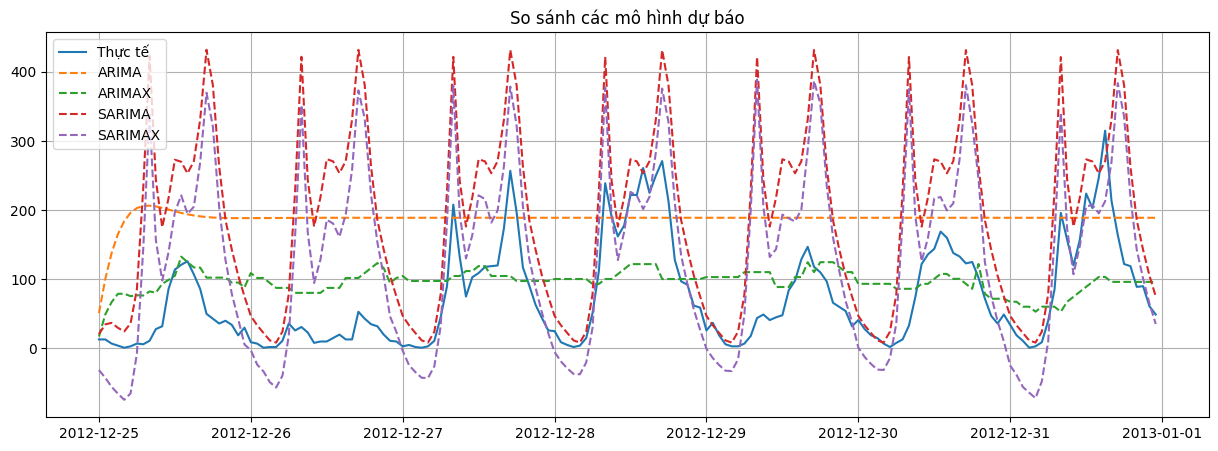

   Mô hình         MAE        RMSE         MAPE
0    ARIMA  122.257913  134.515521  1512.528808
1   ARIMAX   62.029683   72.262666   692.470673
2   SARIMA  113.721577  151.108323   423.958271
3  SARIMAX   83.906981  114.548633   514.776462


In [31]:
# So sánh tất cả các mô hình
plt.figure(figsize=(15,5))
plt.plot(test['cnt'], label='Thực tế')
plt.plot(forecast_arima, label='ARIMA', linestyle='--')
plt.plot(forecast_arimax, label='ARIMAX', linestyle='--')
plt.plot(forecast_sarima, label='SARIMA', linestyle='--')
plt.plot(forecast_sarimax, label='SARIMAX', linestyle='--')
plt.legend()
plt.title("So sánh các mô hình dự báo")
plt.grid()
plt.show()

# Bảng tổng hợp kết quả
results = {
    "Mô hình": ["ARIMA", "ARIMAX", "SARIMA", "SARIMAX"],
    "MAE": [mae_arima, mae_arimax, mae_sarima, mae_sarimax],
    "RMSE": [rmse_arima, rmse_arimax, rmse_sarima, rmse_sarimax],
    "MAPE": [mape_arima, mape_arimax, mape_sarima, mape_sarimax]
}

results_df = pd.DataFrame(results)
print(results_df)

### 📌 Tổng kết mô hình dự báo chuỗi thời gian – Dữ liệu Bike Sharing

- **Họ và tên**: Nguyễn Đức Linh
- **Mục tiêu**: Dự báo số lượt thuê xe đạp (`cnt`) theo giờ, sử dụng các mô hình chuỗi thời gian ARIMA, ARIMAX, SARIMA, SARIMAX.

---

#### ✅ Thông tin mô hình và tham số đã sử dụng:

| Mô hình    | Tham số sử dụng                        | Có biến ngoại sinh? | Có mùa vụ? |
|------------|----------------------------------------|---------------------|------------|
| ARIMA      | (p=2, d=0, q=2)                        | ❌                  | ❌         |
| ARIMAX     | (p=2, d=0, q=2), exog: temp, holiday, weekday | ✅            | ❌         |
| SARIMA     | (p=2, d=0, q=2), (P=1, D=0, Q=1, s=24) | ❌                  | ✅         |
| SARIMAX    | (p=2, d=0, q=2), (P=1, D=0, Q=1, s=24), exog: temp, holiday, weekday | ✅ | ✅ |

> ✅ Ghi chú:
- `d=0` vì chuỗi đã dừng theo kết quả ADF Test (p-value < 0.05).
- `s=24` vì dữ liệu theo giờ, nên chu kỳ mùa vụ là 24 giờ.
- p=2, q=2 dựa trên phân tích các biểu đồ ACF và PACF.


---
#### 📌 Phân tích chi tiết từng mô hình:

- **ARIMA (2,0,2)**:
  - ✅ Ưu điểm: Đơn giản, dễ cài đặt, tốc độ xử lý nhanh.
  - ❌ Nhược điểm: Không xử lý được chu kỳ theo giờ hoặc biến ngoại sinh → đường dự báo phẳng so với thực tế → sai số rất lớn.
  - 🔍 Phân tích: Không phù hợp với dữ liệu có tính mùa vụ rõ ràng như bài toán này.

- **ARIMAX (2,0,2 + temp, holiday, weekday)**:
  - ✅ Ưu điểm: Tận dụng biến thời tiết (nhiệt độ) và ngày lễ → dự báo chính xác ngắn hạn.

- **SARIMA (2,0,2)(1,0,1,24)**:
  - ✅ Ưu điểm: Mô hình hóa tốt chu kỳ 24 giờ, bắt được dao động theo giờ trong ngày.

- **SARIMAX (2,0,2)(1,0,1,24) + temp, holiday, weekday**:
  - ✅ Ưu điểm: Kết hợp cả yếu tố chu kỳ và ngoại sinh → mô hình toàn diện nhất về mặt lý thuyết.
  - ❌ Nhược điểm: Mô hình phức tạp hơn, dễ overfit nếu chọn sai tham số.
  - 🔍 Phân tích: Cân bằng giữa dự báo ngắn hạn và dài hạn, phù hợp khi có đầy đủ dữ liệu.
